In [1]:
import warnings
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

sys.path.append('../source/')

from eda import (
    score_mi_plot, 
    componentes_principales,
    scree_plot)

# **Config**
---

In [2]:
random_seed = 12354
sns.set(style="darkgrid")
sns.set(font_scale=1)
pd.set_option('display.float_format', '{:,.5f}'.format)
title_data = 'Temperature prediction'
paleta = sns.color_palette("tab10").as_hex()
warnings.filterwarnings("ignore")

# **Data**
---

In [3]:
data = pd.read_csv('../data/data_final_modelo.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   key                  3214 non-null   int64  
 1   active_power_sum     3214 non-null   float64
 2   reactive_power_sum   3214 non-null   float64
 3   minutes_process_sum  3214 non-null   float64
 4   active_months        3214 non-null   int64  
 5   bulk_1               3214 non-null   float64
 6   bulk_2               3214 non-null   float64
 7   bulk_3               3214 non-null   float64
 8   bulk_4               3214 non-null   float64
 9   bulk_5               3214 non-null   float64
 10  bulk_6               3214 non-null   float64
 11  bulk_7               3214 non-null   float64
 12  bulk_8               3214 non-null   float64
 13  bulk_9               3214 non-null   float64
 14  bulk_10              3214 non-null   float64
 15  bulk_11              3214 non-null   f

# **Split**
---

The data is divided between the possible predictors and the dependent variable.

In [4]:
X = data.drop(['key','temperature_sum'], axis=1)
y = data['temperature_sum']

# **Feature Selection**
---

Mutual information will be used to identify how much each predictor can explain the variable to be predicted.

In [5]:
score_mi = mutual_info_regression(X, y, random_state=random_seed)

In [6]:
d_scores_mi = dict(zip(X.columns.tolist(), score_mi.tolist()))
d_scores_mi = {k:v for k,v in sorted(d_scores_mi.items(), key=lambda item: item[1])}

In [7]:
scores_mi = list(d_scores_mi.values())
features_mi = list(d_scores_mi.keys())

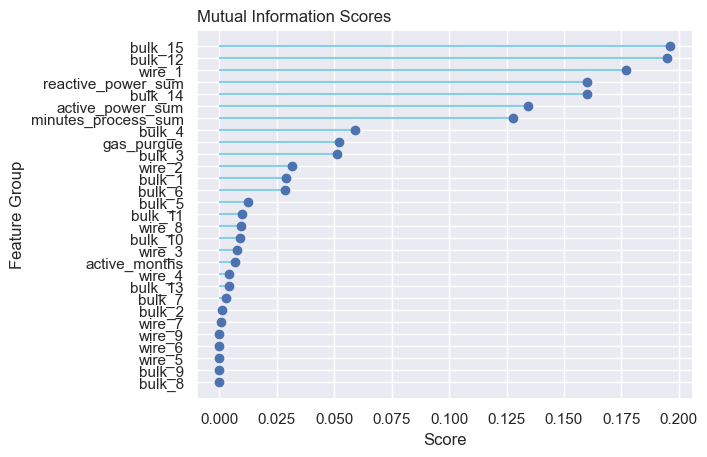

In [8]:
score_mi_plot(scores_mi,features_mi)

- On its own, a predictor is not capable of explaining temperature to a large extent. Most of the material-related variables like "bulk" and "wire" have little to no relationship with temperature. In contrast, bulk_15, bulk_12, wire_1, and bulk_14 explain the target variable better. 

- The issue with the material-related variables is that their composition is not known, making it difficult to determine or explain the outcome from a business perspective.

- Reactive energy (reactive_power_sum), active energy (active_power_sum), processed minutes (minutes_process_sum), and gas purge (gas_purge) are among the top variables that best explain temperature.


# **Correlation of predictors**
---

**All Features**


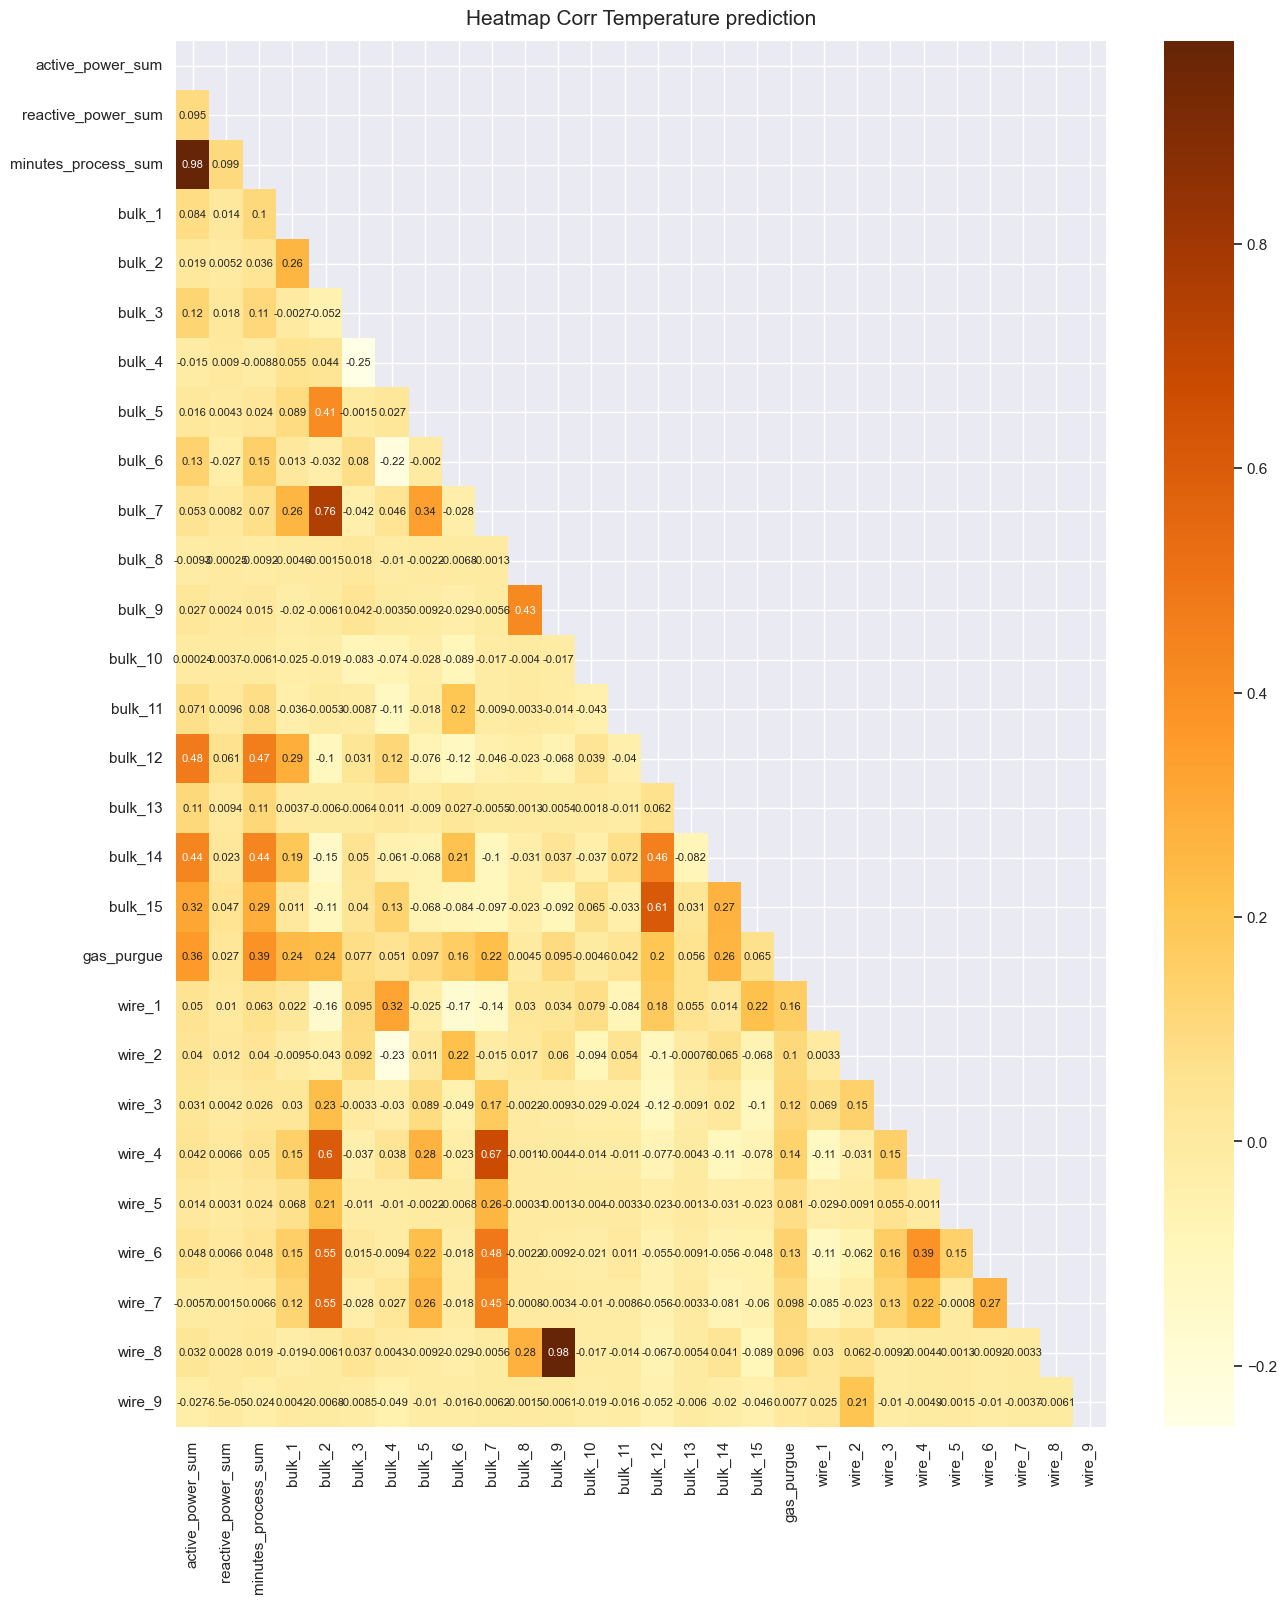

In [9]:
plt.figure(figsize=[15, 18])
dt_temporal = data.select_dtypes(include=['float64', 'int32']).drop(
    [
        'temperature_sum'
    ],
    axis=1
)
mask = np.triu(np.ones_like(dt_temporal.corr()))
ax = sns.heatmap(
    dt_temporal.corr(),
    cmap='YlOrBr',
    annot=True,
    mask=mask,
    annot_kws={'size': 8}
)

ax.set_title(f'Heatmap Corr {title_data}', fontdict={'fontsize':15}, pad=12);

-The correlation level, most variables show weak correlations, with the exception of relationships between materials. Interestingly, there is a strong correlation between active energy and processing time. The longer it takes to process the steel arc, the more active energy will be consumed.


In [10]:
corr_data = X.corr().stack().reset_index()
corr_data.columns = ['Variable_1', 'Variable_2', 'r']
corr_data = corr_data.loc[corr_data['Variable_1'] != corr_data['Variable_2'], :]
corr_data['abs_r'] = np.abs(corr_data['r'])
corr_data = corr_data.sort_values('abs_r', ascending=False)
corr_data.head(20)

,Variable_1,Variable_2,r,abs_r
334,bulk_9,wire_8,0.98067,0.98067
739,wire_8,bulk_9,0.98067,0.98067
56,minutes_process_sum,active_power_sum,0.97799,0.97799
2,active_power_sum,minutes_process_sum,0.97799,0.97799
121,bulk_2,bulk_7,0.75753,0.75753
256,bulk_7,bulk_2,0.75753,0.75753
625,wire_4,bulk_7,0.67398,0.67398
274,bulk_7,wire_4,0.67398,0.67398
409,bulk_12,bulk_15,0.61018,0.61018
490,bulk_15,bulk_12,0.61018,0.61018


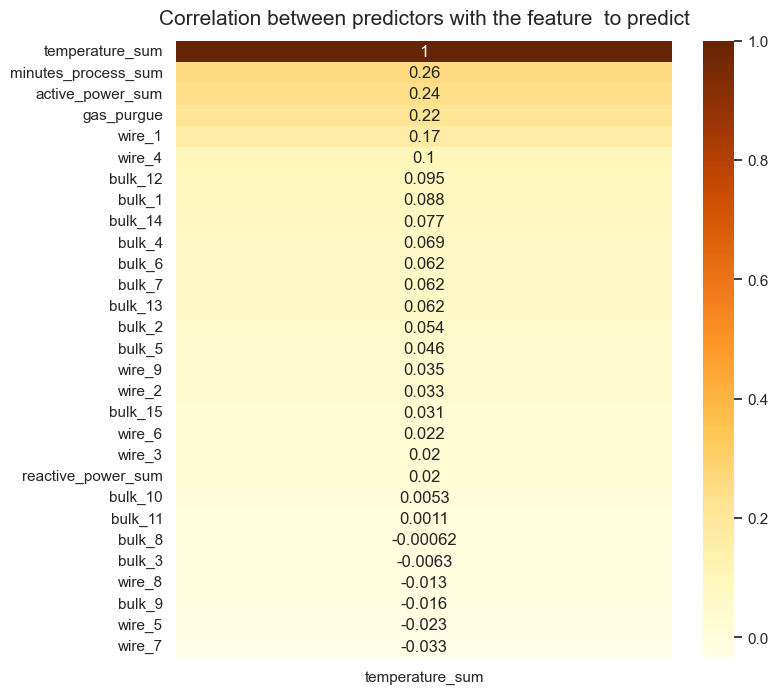

In [11]:
plt.figure(figsize=[8, 8])
dt_temporal = data.select_dtypes(include=['float64', 'int32'])


ax = sns.heatmap(
    dt_temporal.corr()[
         ['temperature_sum']
    ].sort_values(by='temperature_sum', ascending=False),
    cmap='YlOrBr',
    annot=True,
)
ax.set_title(
    f'Correlation between predictors with the feature  to predict', 
    fontdict={'fontsize':15}, pad=12);

plt.show()

The variables for processing time in minutes, active energy, and gas purge have a weak correlation with temperature, but it's better compared to the other variables. However, it is possible that other types of relationships exist, as indicated by mutual information.

In [12]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
active_power_sum,"3,214.00000",3.10283,1.39714,0.18623,2.12634,2.99054,3.90115,17.49650
reactive_power_sum,"3,214.00000",2.09461,12.68949,-714.59164,1.59902,2.22893,2.89914,12.58799
minutes_process_sum,"3,214.00000",13.24163,5.53983,0.95000,9.51700,12.82550,16.38300,69.81700
active_months,"3,214.00000",1.00000,0.00000,1.00000,1.00000,1.00000,1.00000,1.00000
bulk_1,"3,214.00000",3.07685,11.72209,0.00000,0.00000,0.00000,0.00000,185.00000
bulk_2,"3,214.00000",1.73211,20.93728,0.00000,0.00000,0.00000,0.00000,325.00000
bulk_3,"3,214.00000",45.99098,73.64264,0.00000,0.00000,0.00000,76.00000,454.00000
bulk_4,"3,214.00000",32.93591,55.55428,0.00000,0.00000,0.00000,65.00000,281.00000
bulk_5,"3,214.00000",2.56409,20.64392,0.00000,0.00000,0.00000,0.00000,603.00000
bulk_6,"3,214.00000",21.28563,54.85453,0.00000,0.00000,0.00000,0.00000,503.00000


- The situation with the material-related variables is that values other than zero are mostly concentrated above the 75th percentile.

- The variable active_months is discarded, since the steel working process occurred at some point during a month in all cases.

# **Work strategies**
---

In [13]:
X.columns

Index(['active_power_sum', 'reactive_power_sum', 'minutes_process_sum',
       'active_months', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5',
       'bulk_6', 'bulk_7', 'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15', 'gas_purgue', 'wire_1', 'wire_2',
       'wire_3', 'wire_4', 'wire_5', 'wire_6', 'wire_7', 'wire_8', 'wire_9'],
      dtype='object')

Three strategies are defined to consider:
1. Use only the variables: gas_purge, reactive_power_sum, minutes_process_sum, or active_power_sum, as these are variables whose meaning and behavior are understood. The last two can be use only one due to their high correlation, which may indicate multicollinearity; however, they could be included if proven otherwise.

2. Consider the variables in option one along with a reduction of the material variables bulk and wire using a PCA technique.

3. Use component reduction on the entire dataset.

4. Use the variables from option one along with the bulk and wire material variables that contribute information for predicting temperature.

# **First Strategy**
---

The variables will be analyzed with the first strategy: Use only the variables: gas_purge, reactive_power_sum, minutes_process_sum, or active_power_sum, as these are variables whose meaning and behavior are understood. The last two can be use only one due to their high correlation, which may indicate multicollinearity; however, they could be included if proven otherwise.

In [14]:
data_first = data[[
    'active_power_sum', 
    'reactive_power_sum', 
    'minutes_process_sum', 
    'gas_purgue', 
    'temperature_sum']]

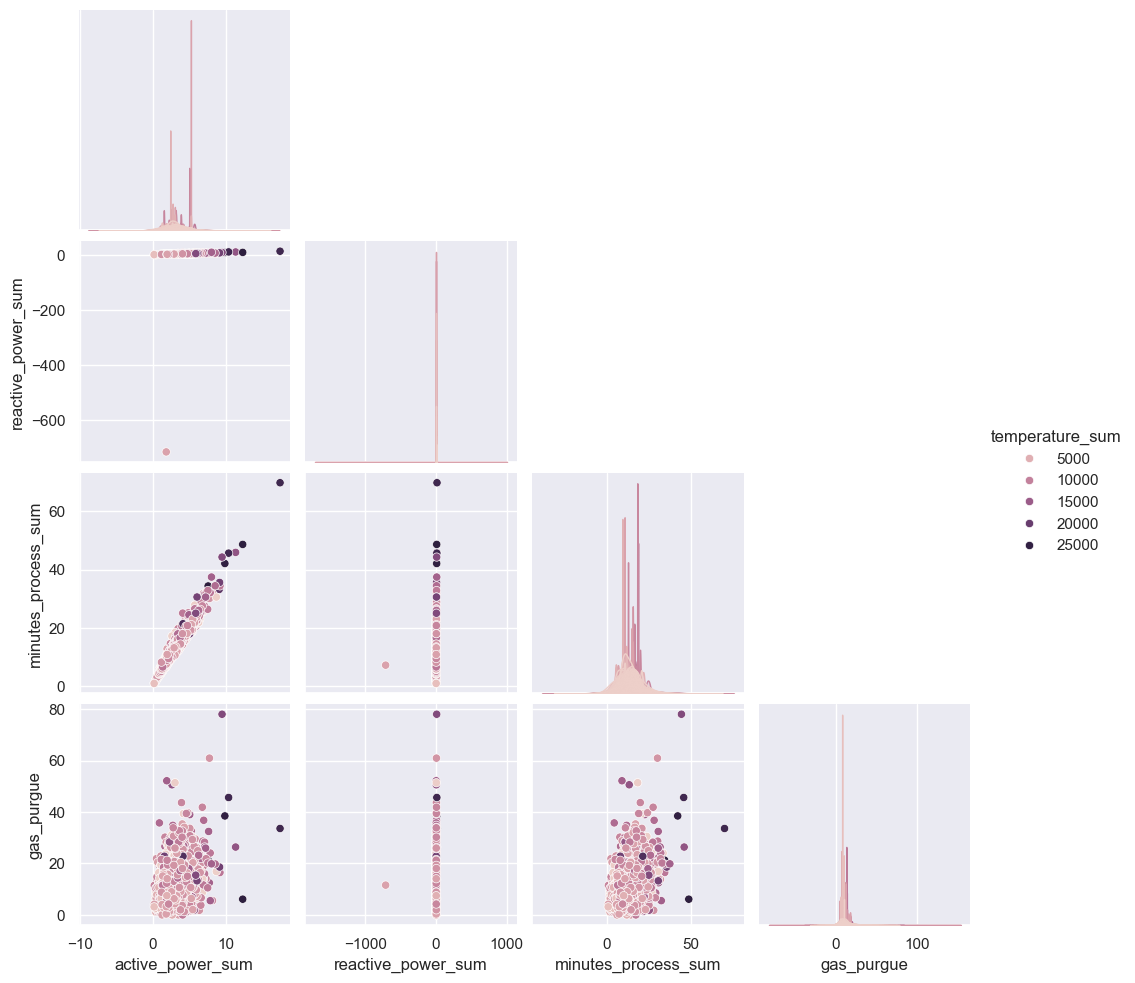

In [15]:
sns.pairplot(data_first, hue="temperature_sum", corner=True)
plt.show()

- It is evident that the more processing minutes are used, the more active energy is consumed in steel manufacturing.
- Although an anomaly in active energy is evident, there is a trend that higher active energy will tend to result in reactive energy.
- The gas consumption is not necessarily directly related to active energy consumption, although it is not related to reactive energy

In [16]:
data_first.describe()

,active_power_sum,reactive_power_sum,minutes_process_sum,gas_purgue,temperature_sum
count,"3,214.00000","3,214.00000","3,214.00000","3,214.00000","3,214.00000"
mean,3.10283,2.09461,13.24163,11.07926,"6,440.66490"
std,1.39714,12.68949,5.53983,6.18126,"3,668.55298"
min,0.18623,-714.59164,0.95000,0.00000,"1,204.00000"
25%,2.12634,1.59902,9.51700,7.09115,"4,692.00000"
50%,2.99054,2.22893,12.82550,9.85514,"6,362.00000"
75%,3.90115,2.89914,16.38300,13.80562,"8,040.75000"
max,17.49650,12.58799,69.81700,77.99504,"25,637.00000"


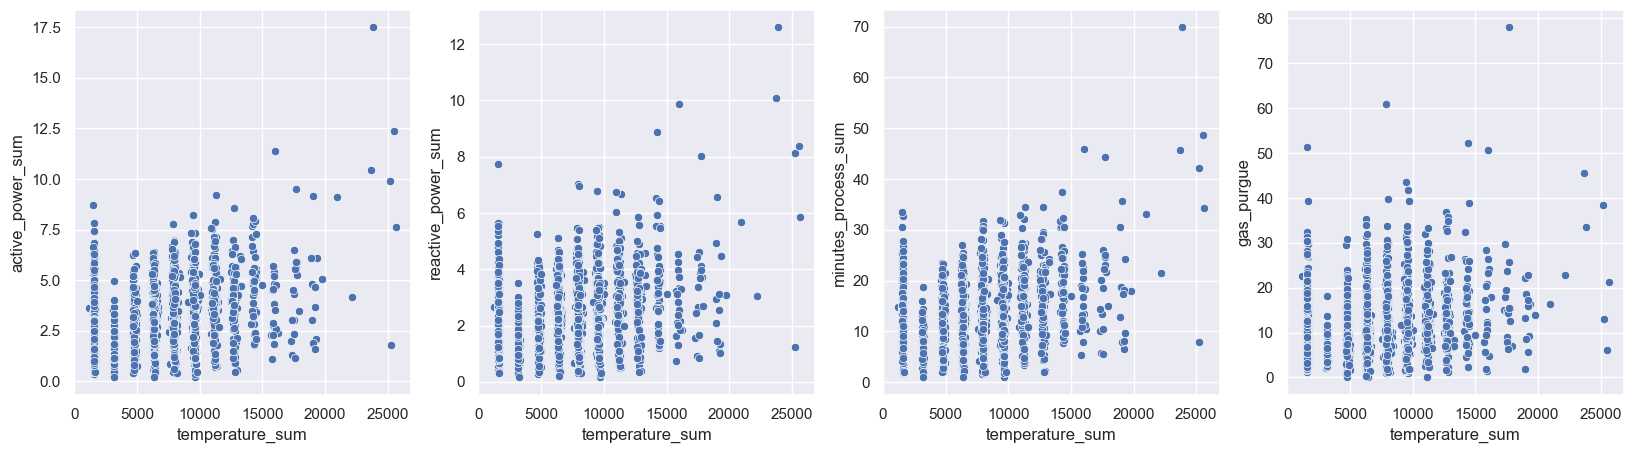

In [17]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))
sns.scatterplot(data_first, x="temperature_sum",y="active_power_sum", ax=ax[0])
sns.scatterplot(data_first[data_first['reactive_power_sum']>0], x="temperature_sum",y="reactive_power_sum", ax=ax[1])
#ax[1].set(yscale="log")
#ax[1].set(xscale="log")
sns.scatterplot(data_first, x="temperature_sum",y="minutes_process_sum", ax=ax[2])
sns.scatterplot(data_first, x="temperature_sum",y="gas_purgue", ax=ax[3])
plt.show()

It is inspected whether there is a linear correlation between the predictors and the temperature, but a weak relationship is evident, as the data shows a lot of dispersion

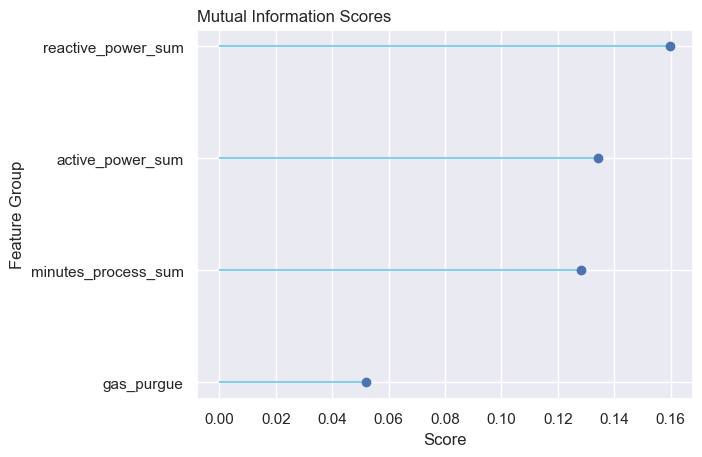

In [18]:
score_mi = mutual_info_regression(
    data_first.drop('temperature_sum', axis=1), 
    data_first['temperature_sum'], 
    random_state=random_seed)
d_scores_mi = dict(zip(data_first.columns.tolist(), score_mi.tolist()))
d_scores_mi = {k:v for k,v in sorted(d_scores_mi.items(), key=lambda item: item[1])}
scores_mi = list(d_scores_mi.values())
features_mi = list(d_scores_mi.keys())
score_mi_plot(scores_mi,features_mi)

The variables show some relationship with the dependent variable, although it is not a substantial relationship, and they do not explain temperature very well on their own

In [19]:
data_first=data[[
    'key',
    'active_power_sum', 
    'reactive_power_sum', 
    'minutes_process_sum', 
    'gas_purgue', 
    'temperature_sum']]

In [20]:
data_first.to_csv('../data/first_strategy.csv', index=False)

# **Second Strategy**
---

The variables will be analyzed with the second strategy: Consider the variables in option one along with a reduction of the material variables bulk and wire using a PCA technique.

In [21]:
data_second = data.drop([
    'key', 
    'temperature_sum',
    'active_power_sum',
    'reactive_power_sum',
    'minutes_process_sum',
    'gas_purgue',
    'active_months'], axis=1)
data_second.columns

Index(['bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6', 'bulk_7',
       'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12', 'bulk_13',
       'bulk_14', 'bulk_15', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_5',
       'wire_6', 'wire_7', 'wire_8', 'wire_9'],
      dtype='object')

PCA is instantiated with a minimum explained variance of 0.75 and a maximum of 10 components.Regarding the variables 'Bulk' and 'Wire

In [22]:
data_df, final_pca, info = componentes_principales(
    data_second,
    min_explained_variance=0.75,
    min_component=10,
    random_state=random_seed)

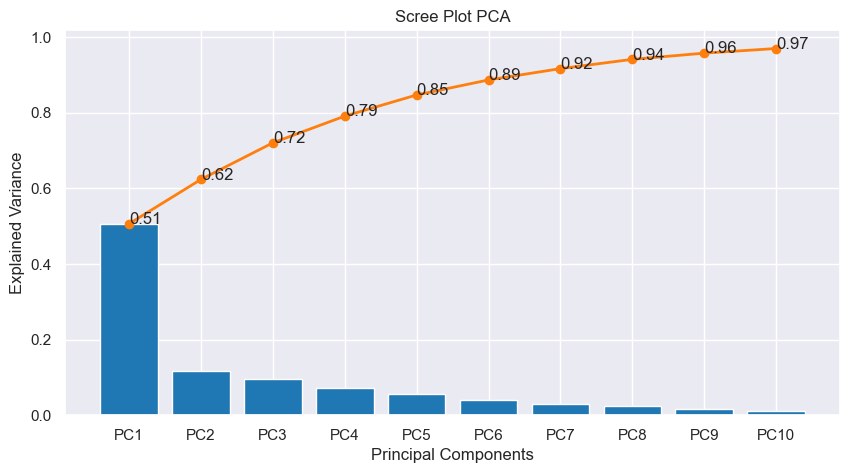

In [23]:
scree_plot(final_pca, paleta, title='Scree Plot PCA')

The first three components explain 72% of the variance. The fourth and fifth components are not selected because this linear combination will be combined with the variables from the first strategy.

In [24]:
pca_components =  PCA(n_components=3, random_state=random_seed)
pca_components.fit(data_second)
print(pca_components.explained_variance_ratio_)
data_df_pca = pca_components.transform(data_second)

[0.50599602 0.11722891 0.09670793]


In [25]:
data_second_strategy = pd.concat(
    [
    data[[
    'key', 
    'temperature_sum',
    'active_power_sum',
    'reactive_power_sum',
    'minutes_process_sum',
    'gas_purgue',
    ]],
    pd.DataFrame(data_df_pca,
                 columns=['C1','C2','C3']),
    ],axis=1
)

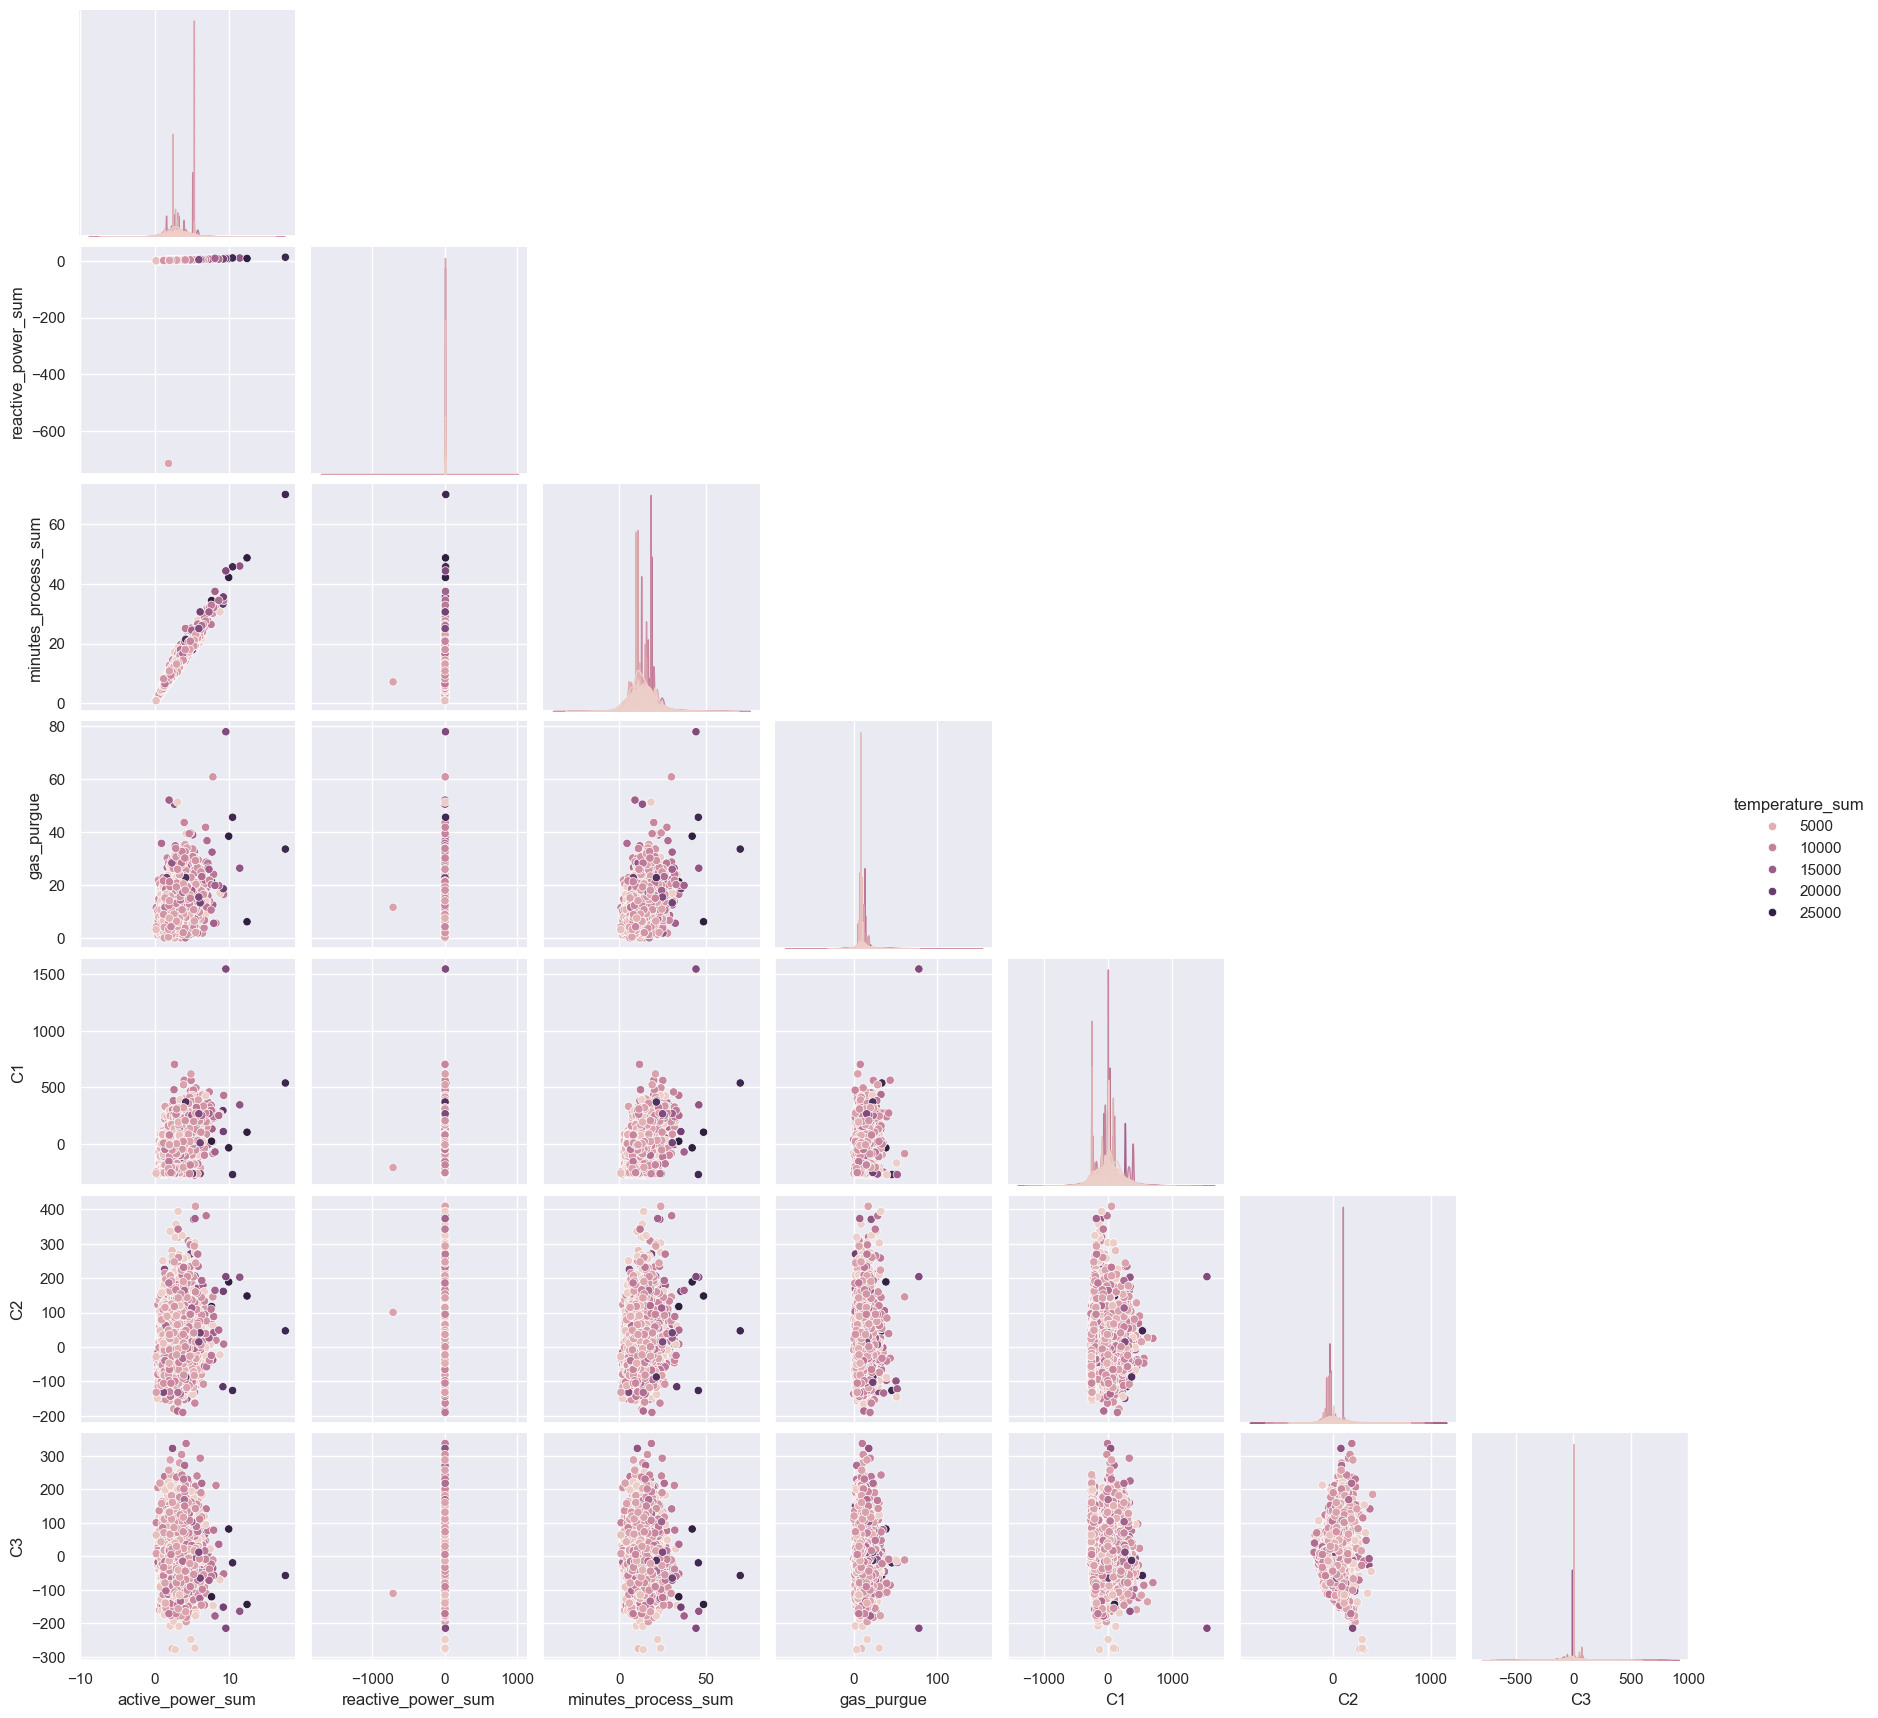

In [26]:
sns.pairplot(
    data_second_strategy.drop('key', axis=1), 
    hue="temperature_sum", 
    corner=True)
plt.show()

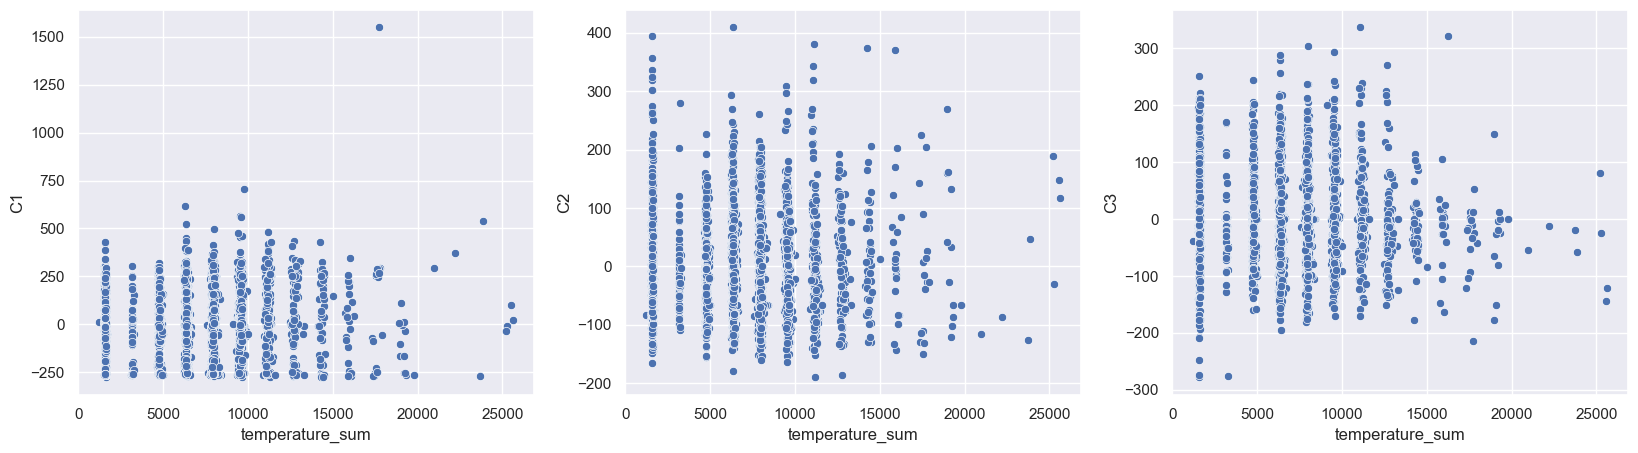

In [27]:
fig, ax = plt.subplots(1, 3, figsize = (20, 5))
sns.scatterplot(data_second_strategy, x="temperature_sum",y="C1", ax=ax[0])
sns.scatterplot(data_second_strategy, x="temperature_sum",y="C2", ax=ax[1])
sns.scatterplot(data_second_strategy, x="temperature_sum",y="C3", ax=ax[2])
plt.show()

No linear relationship with the temperature variable is evident

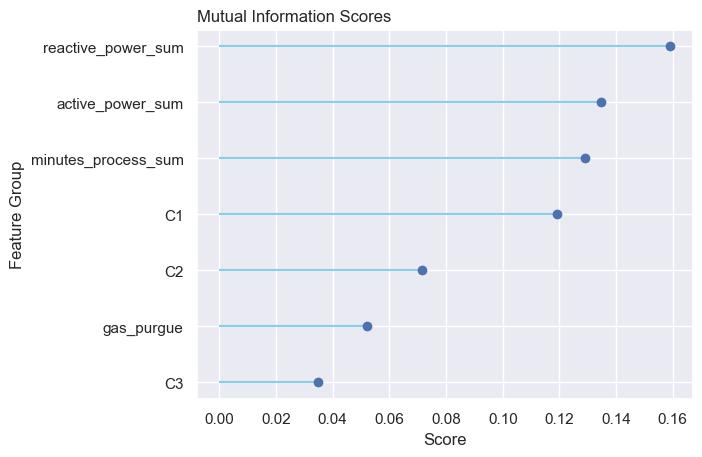

In [28]:
score_mi = mutual_info_regression(
    data_second_strategy.drop(['key', 'temperature_sum'], axis=1), 
    data_second_strategy['temperature_sum'], 
    random_state=random_seed)
d_scores_mi = dict(zip(data_second_strategy.drop(['key', 'temperature_sum'], axis=1).columns.tolist(), score_mi.tolist()))
d_scores_mi = {k:v for k,v in sorted(d_scores_mi.items(), key=lambda item: item[1])}
scores_mi = list(d_scores_mi.values())
features_mi = list(d_scores_mi.keys())
score_mi_plot(scores_mi,features_mi)

The variables show some relationship with the dependent variable, although it is not a substantial relationship, and they do not explain temperature very well on their own

In [29]:
data_second_strategy.to_csv('../data/second_strategy.csv', index=False)

# **Third Strategy**
---

The variables will be analyzed with the third strategy: Use component reduction on the entire dataset.

In [30]:
data_third = data.drop([
    'key',
    'temperature_sum',
    'active_months'], axis=1)
data_third.columns

Index(['active_power_sum', 'reactive_power_sum', 'minutes_process_sum',
       'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6', 'bulk_7',
       'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12', 'bulk_13',
       'bulk_14', 'bulk_15', 'gas_purgue', 'wire_1', 'wire_2', 'wire_3',
       'wire_4', 'wire_5', 'wire_6', 'wire_7', 'wire_8', 'wire_9'],
      dtype='object')

The explained variable is increased to 85%, and at least 3 components should be considered.

In [31]:
data_df, final_pca, info = componentes_principales(
    data_third,
    min_explained_variance=0.85,
    min_component=3)

The image describes that 5 components explain approximately 84% of variance,  close to the minimum explained variance that was considered previously.

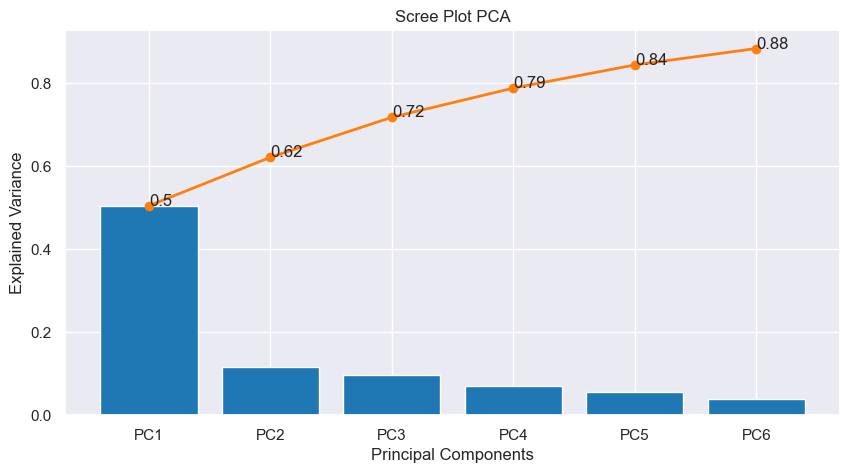

In [32]:
scree_plot(final_pca, paleta, title='Scree Plot PCA')

In [33]:
pca_components =  PCA(n_components=5, random_state=random_seed)
pca_components.fit(data_third)
print(pca_components.explained_variance_ratio_)
data_df_pca = pca_components.transform(data_third)

[0.50410567 0.11680429 0.09632075 0.07031203 0.05568049]


In [34]:
data_third_trategy = pd.concat(
    [
    data[[
    'key', 
    'temperature_sum'
    ]],
    pd.DataFrame(data_df_pca,
                 columns=['C1','C2','C3', 'C4', 'C5']),
    ],axis=1
)
data_third_trategy

,key,temperature_sum,C1,C2,C3,C4,C5
0,1,"8,007.00000",20.88850,-39.17555,-28.85761,29.09527,-22.80295
1,10,"12,678.00000",22.18162,-63.91922,16.61842,59.46159,-69.01695
2,100,"6,295.00000",21.03320,-26.25830,-21.93474,31.55612,-36.21207
3,1000,"9,575.00000",-251.30467,3.99810,158.15087,-53.95510,43.78298
4,1001,"14,293.00000",-253.70081,-18.05334,114.83498,-55.43850,14.96360
...,...,...,...,...,...,...,...
3209,995,"9,542.00000",-3.27465,-97.94387,-16.63067,-5.72901,50.51911
3210,996,"7,986.00000",6.96749,-105.44653,-32.75088,9.37505,77.10562
3211,997,"4,762.00000",-13.91689,-46.96295,-13.19838,-29.78941,-63.18561
3212,998,"9,482.00000",-254.73121,-104.84294,5.68684,-38.86811,15.45676


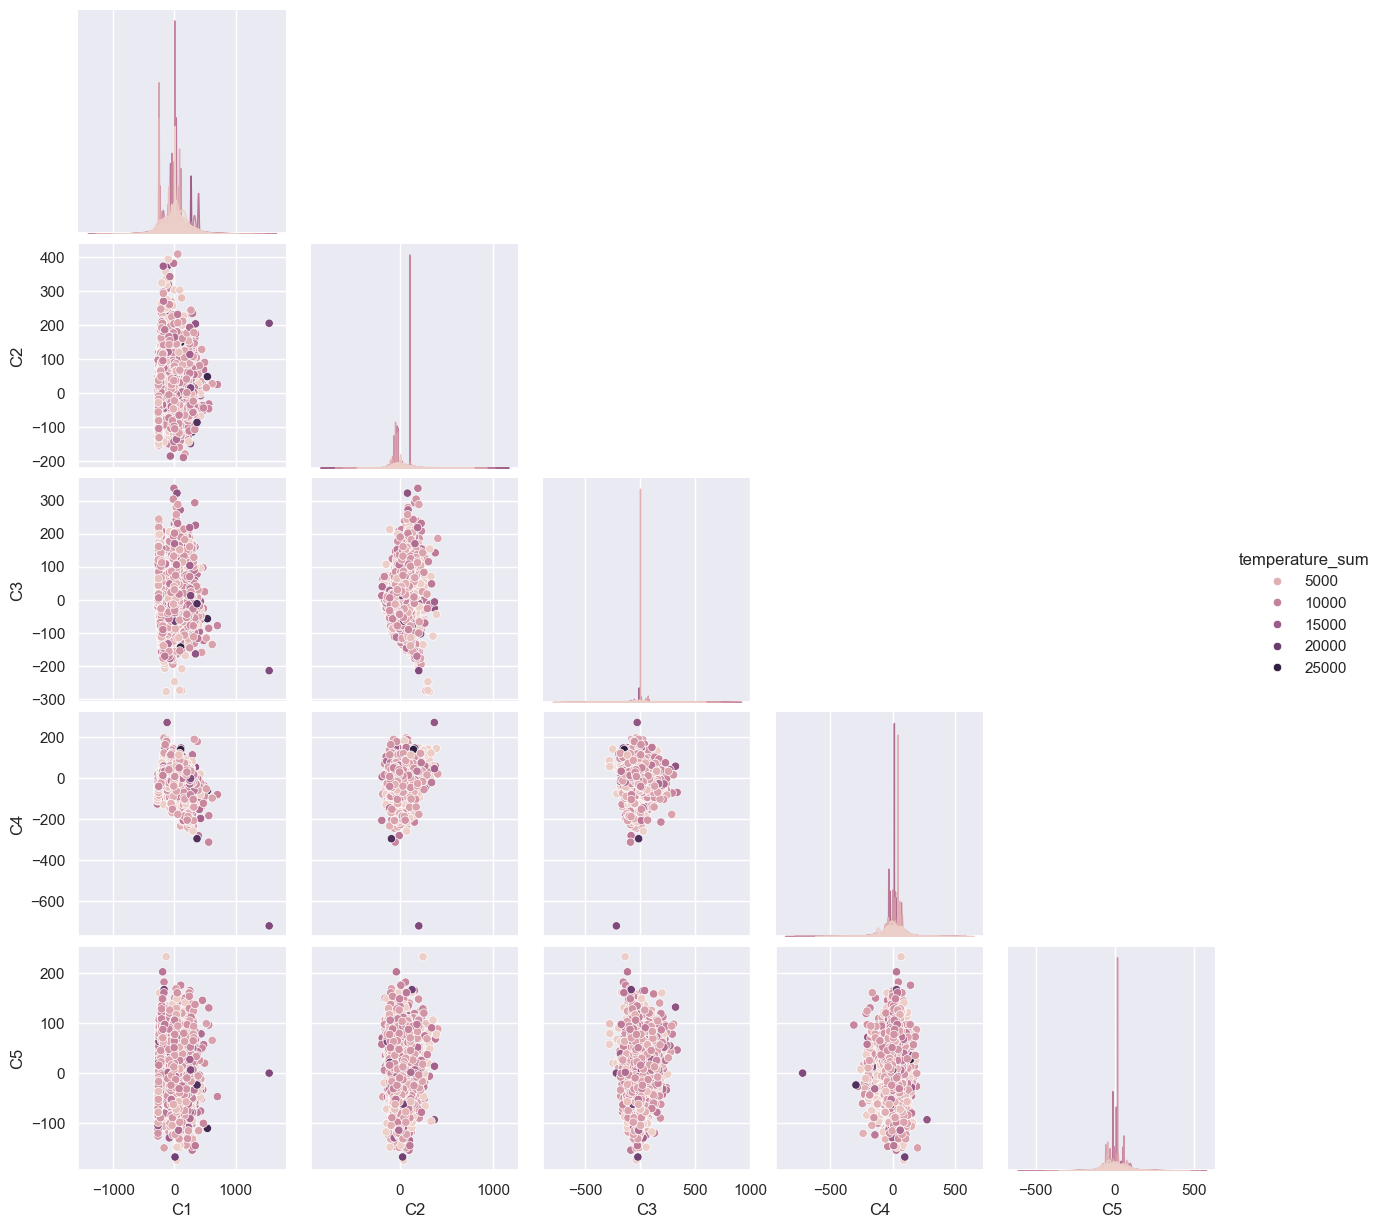

In [35]:
sns.pairplot(
    data_third_trategy.drop('key', axis=1), 
    hue="temperature_sum", 
    corner=True)
plt.show()

There is no evidence of a linear relationship.

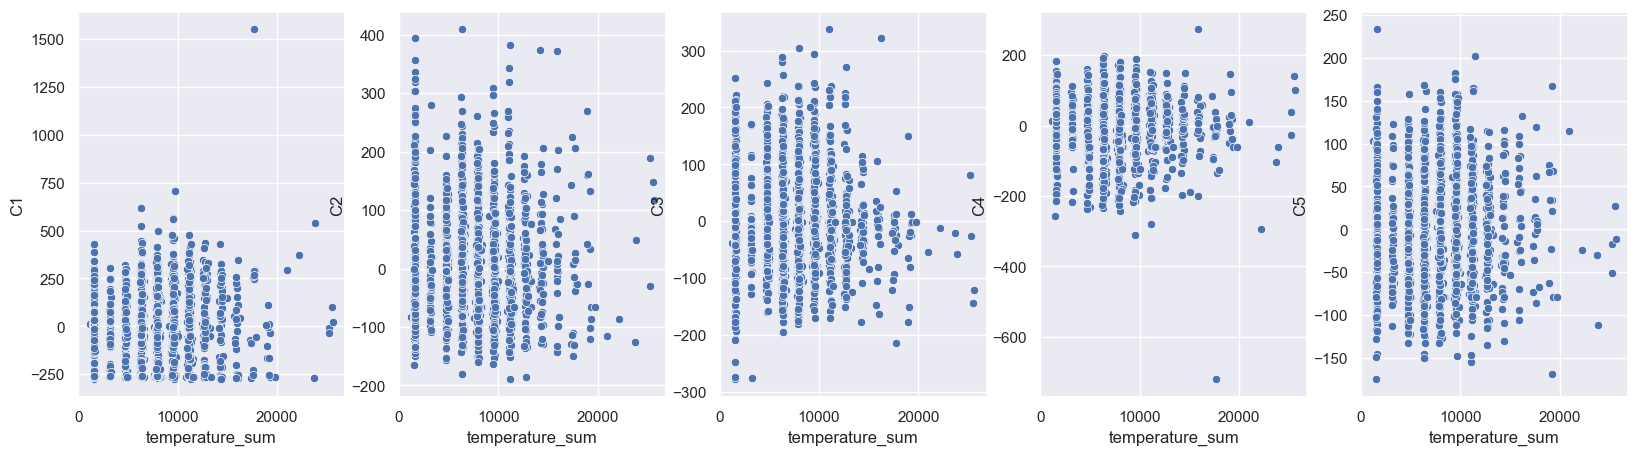

In [36]:
fig, ax = plt.subplots(1, 5, figsize = (20, 5))
sns.scatterplot(data_third_trategy, x="temperature_sum",y="C1", ax=ax[0])
sns.scatterplot(data_third_trategy, x="temperature_sum",y="C2", ax=ax[1])
sns.scatterplot(data_third_trategy, x="temperature_sum",y="C3", ax=ax[2])
sns.scatterplot(data_third_trategy, x="temperature_sum",y="C4", ax=ax[3])
sns.scatterplot(data_third_trategy, x="temperature_sum",y="C5", ax=ax[4])
plt.show()

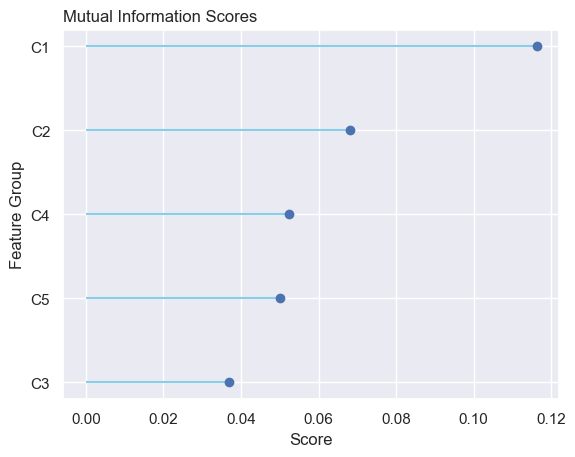

In [37]:
score_mi = mutual_info_regression(
    data_third_trategy.drop(['key', 'temperature_sum'], axis=1), 
    data_third_trategy['temperature_sum'], 
    random_state=random_seed)
d_scores_mi = dict(zip(data_third_trategy.drop(['key', 'temperature_sum'], axis=1).columns.tolist(), score_mi.tolist()))
d_scores_mi = {k:v for k,v in sorted(d_scores_mi.items(), key=lambda item: item[1])}
scores_mi = list(d_scores_mi.values())
features_mi = list(d_scores_mi.keys())
score_mi_plot(scores_mi,features_mi)

The variables of C# show some relationship with the dependent variable, although it is not a substantial relationship, and they do not explain temperature very well on their own

In [38]:
data_third_trategy.to_csv('../data/third_strategy.csv', index=False)

# **Fourth strategy**
---
The variables will be analyzed with the fourth strategy. Use the variables from option one along with the bulk and wire material variables that contribute information for predicting temperature.

In [39]:
data_fourth = data[[
    'key',
    'active_power_sum', 
    'reactive_power_sum', 
    'minutes_process_sum', 
    'gas_purgue', 
    'temperature_sum',
    'wire_1',
    'bulk_12',
    'bulk_14',
    'bulk_15']]

In [40]:
data_fourth.columns

Index(['key', 'active_power_sum', 'reactive_power_sum', 'minutes_process_sum',
       'gas_purgue', 'temperature_sum', 'wire_1', 'bulk_12', 'bulk_14',
       'bulk_15'],
      dtype='object')

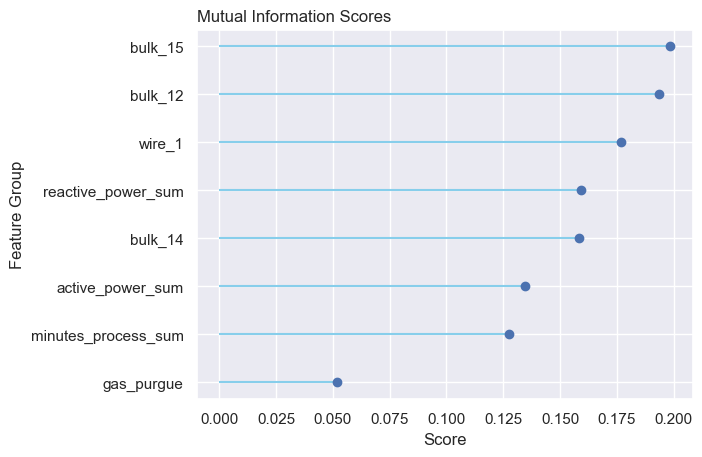

In [41]:
score_mi = mutual_info_regression(
    data_fourth.drop(['key', 'temperature_sum'], axis=1), 
    data_fourth['temperature_sum'], 
    random_state=random_seed)
d_scores_mi = dict(zip(data_fourth.drop(['key', 'temperature_sum'], axis=1).columns.tolist(), score_mi.tolist()))
d_scores_mi = {k:v for k,v in sorted(d_scores_mi.items(), key=lambda item: item[1])}
scores_mi = list(d_scores_mi.values())
features_mi = list(d_scores_mi.keys())
score_mi_plot(scores_mi,features_mi)

The variables show some relationship with the dependent variable, although it is not a substantial relationship, and they do not explain temperature very well on their own

In [42]:
data_fourth.to_csv('../data/fourth_strategy.csv', index=False)